# Analisis Pengaruh Teknik Preprocessing terhadap Klasifikasi Ginjal Normal dan Batu Ginjal Menggunakan Fitur Gray Level Co-occurrence Matrix (GLCM) serta Perbandingan Algoritma Support Vector Machine (SVM), Random Forest, dan K-Nearest Neighbor (KNN)
## Percobaan 3 — Preprocessing: Grayscale + Resize + CLAHE + Sharpening (4 Preprocessing)
### Nama Anggota
- Muhammad Andika Azkiya : F1D02410076
- Gusti Ayu Marsha Widyaswari : F1D02410007
- Ahmad Yadan Ulya Munaji : F1D02410100
- Revano Januar Adiguna Prawira : F1D02410146

In [19]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

## Import Library

Cell ini mengimpor seluruh library yang dibutuhkan selama proses preprocessing, ekstraksi fitur GLCM, visualisasi data, hingga klasifikasi citra ginjal.

Library `os` digunakan untuk membaca struktur folder dataset dan melakukan iterasi pada setiap file citra secara otomatis. `OpenCV (cv2)` digunakan untuk membaca citra, melakukan resize, konversi grayscale, serta berbagai proses pengolahan citra lainnya. Untuk visualisasi citra dan grafik digunakan `Matplotlib (matplotlib.pyplot)`.

`NumPy` digunakan untuk mengelola data dalam bentuk array multidimensi yang efisien untuk pengolahan citra. `Pandas` digunakan untuk menyimpan dan mengelola data hasil ekstraksi fitur dalam bentuk DataFrame. Pembagian dataset menjadi data latih dan data uji dilakukan menggunakan fungsi `train_test_split` dari library `scikit-learn`.

Pada tahap ekstraksi fitur tekstur digunakan fungsi `graycomatrix` dan `graycoprops` dari library `scikit-image` untuk membentuk Gray Level Co-occurrence Matrix (GLCM) serta menghitung fitur tekstur seperti contrast, correlation, energy, dan homogeneity. Selain itu, fungsi `entropy` dari library `SciPy` digunakan untuk menghitung nilai entropi sebagai fitur tambahan yang merepresentasikan kompleksitas tekstur citra.

Tahap klasifikasi dilakukan menggunakan tiga algoritma machine learning, yaitu `RandomForestClassifier` (Random Forest), `SVC` (Support Vector Machine), dan `KNeighborsClassifier` (K-Nearest Neighbor). Evaluasi performa model dilakukan menggunakan berbagai metrik dari `sklearn.metrics`, meliputi accuracy, precision, recall, F1-score, classification report, serta confusion matrix. Visualisasi hasil evaluasi dan analisis data didukung oleh library `Seaborn`.

## Memuat Dataset dan Resize Citra

Cell ini bertugas membaca seluruh citra dari folder `Assets` dan melakukan resize seragam menjadi ukuran **256×256 piksel**.

Setiap subfolder pada direktori `Assets/` dianggap sebagai satu kelas label, yaitu **Normal** dan **Batu Ginjal**. Program melakukan iterasi ke seluruh subfolder, kemudian membaca setiap file citra menggunakan fungsi `cv.imread()`. Citra yang berhasil dibaca selanjutnya di-resize menjadi **256×256 piksel** menggunakan fungsi `cv.resize()`.

Setiap citra yang telah diproses disimpan ke dalam list `data`, label kelas disimpan pada list `labels`, dan nama file disimpan pada list `file_name`. Setelah seluruh data berhasil dimuat, ketiga list tersebut dikonversi menjadi array NumPy untuk meningkatkan efisiensi komputasi pada tahap preprocessing, ekstraksi fitur, dan klasifikasi.

Resize ke ukuran **256×256 piksel** dilakukan agar:

- Seluruh citra memiliki dimensi yang seragam sebelum diproses lebih lanjut.
- Mengurangi perbedaan ukuran citra yang dapat mempengaruhi hasil ekstraksi fitur.
- Mempercepat proses komputasi dibandingkan menggunakan resolusi asli citra.
- Tetap mempertahankan informasi tekstur yang diperlukan untuk ekstraksi fitur GLCM.

Pada akhir proses, program menampilkan jumlah total citra yang berhasil dimuat beserta daftar label kelas yang tersedia pada dataset.

In [ ]:
def resize_image(image, target_size=(256, 256)):
    return cv.resize(image, target_size)

data = []
labels = []
file_name = []

dataset_path = 'Assets'

for sub_folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = resize_image(img, (256, 256))
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f'Total data: {len(data)}')
print(f'Labels: {np.unique(labels)}')

Total data: 200
Labels: ['Normal' 'kidneyStone']


## Visualisasi Distribusi Dataset

Cell ini menampilkan distribusi jumlah citra pada masing-masing kelas dataset ginjal menggunakan diagram batang (*bar chart*). Visualisasi ini bertujuan untuk mengetahui sebaran data serta memastikan apakah dataset memiliki distribusi yang seimbang sebelum dilakukan proses klasifikasi.

Karakteristik Dataset:

- Dataset terdiri dari dua kelas, yaitu **Normal** dan **Batu Ginjal (Kidney Stone)**.
- Jumlah citra pada masing-masing kelas dihitung menggunakan fungsi `np.unique()` dengan parameter `return_counts=True`.
- Total data yang digunakan dalam penelitian berjumlah **200 citra**.
- Distribusi data divisualisasikan menggunakan diagram batang dengan warna berbeda untuk setiap kelas, serta dilengkapi label jumlah data di atas masing-masing batang.

Analisis Karakteristik Data:

- Visualisasi distribusi digunakan untuk melihat keseimbangan jumlah data antar kelas sebelum dilakukan ekstraksi fitur dan klasifikasi.
- Dataset yang relatif seimbang dapat membantu model mempelajari karakteristik setiap kelas secara lebih baik dan mengurangi kemungkinan bias terhadap kelas tertentu.
- Seluruh citra telah melalui proses resize menjadi **256×256 piksel** sehingga memiliki ukuran yang seragam sebelum memasuki tahap preprocessing berikutnya.
- Dataset berisi citra ginjal normal dan ginjal yang mengandung batu ginjal, sehingga perbedaan tekstur pada kedua kelas diharapkan dapat direpresentasikan melalui fitur GLCM yang diekstraksi pada tahap selanjutnya.

Diagram batang ditampilkan menggunakan `Matplotlib`, dengan jumlah citra pada setiap kelas ditampilkan di atas batang untuk mempermudah interpretasi distribusi data.

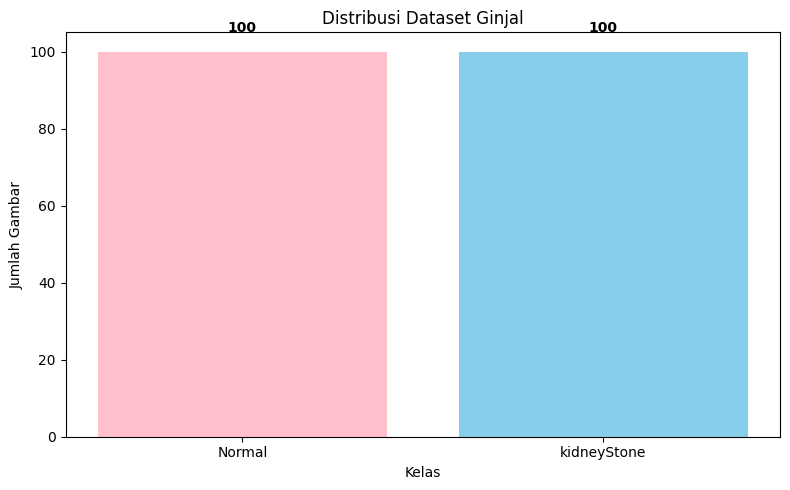

In [22]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color=['pink', 'skyblue'])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Dataset Ginjal')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 5, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Visualisasi Sampel Citra Dataset

Cell ini menampilkan beberapa contoh citra dari setiap kelas dalam dataset menggunakan fungsi `show_sample_images()`.

- Fungsi `show_sample_images()` menerima data citra, label, nama kelas, dan jumlah sampel yang akan ditampilkan untuk setiap kelas.
- Untuk setiap kelas, program mencari indeks citra yang sesuai menggunakan `np.where(labels == cls)`.
- Beberapa citra dari masing-masing kelas kemudian ditampilkan dalam bentuk grid menggunakan `Matplotlib`.
- Jika citra masih dalam format BGR, program mengubahnya terlebih dahulu ke format RGB menggunakan `cv.cvtColor()` agar warna yang ditampilkan sesuai dengan citra asli.
- Setiap citra diberi judul sesuai kelasnya, sedangkan sumbu koordinat dinonaktifkan agar tampilan lebih rapi dan mudah diamati.

Tujuan visualisasi ini adalah untuk memverifikasi bahwa seluruh citra berhasil dibaca dengan benar, label kelas sudah sesuai, serta tidak terdapat data yang rusak atau gagal dimuat.

Analisis Karakteristik Citra:

- Citra kelas **Normal** menunjukkan struktur ginjal tanpa adanya indikasi batu ginjal yang jelas pada area pengamatan.
- Citra kelas **Batu Ginjal (Kidney Stone)** menunjukkan adanya perbedaan pola tekstur dan intensitas yang berkaitan dengan keberadaan batu ginjal.
- Terdapat variasi tingkat kecerahan, kontras, dan detail tekstur antar citra yang dapat disebabkan oleh perbedaan proses akuisisi citra.
- Perbedaan karakteristik tekstur inilah yang akan dieksplorasi lebih lanjut menggunakan metode **Gray Level Co-occurrence Matrix (GLCM)** pada tahap ekstraksi fitur.

Visualisasi sampel citra membantu memberikan gambaran awal mengenai karakteristik dataset sebelum dilakukan preprocessing dan ekstraksi fitur.

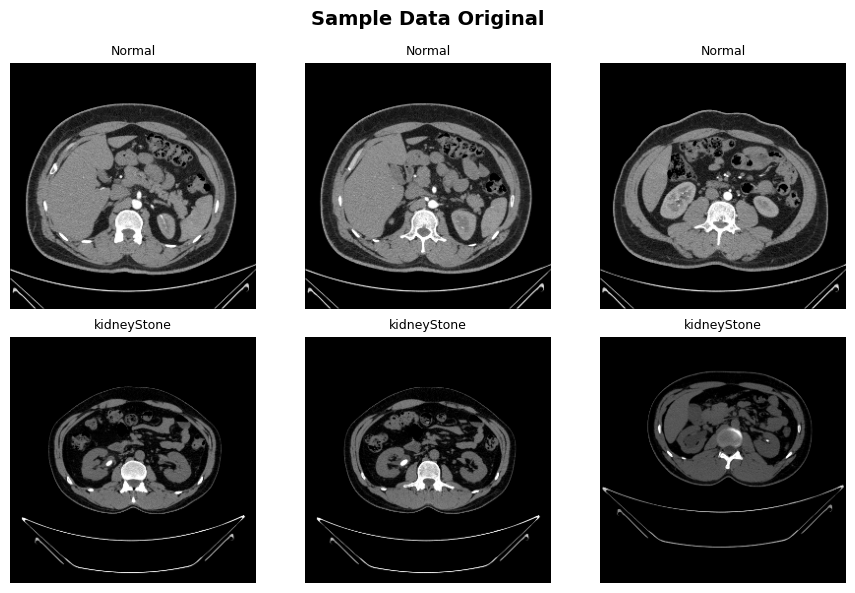

In [23]:
def show_sample_images(images, labels, class_names, title='Sample Images', n=3):
    fig, axes = plt.subplots(len(class_names), n, figsize=(n*3, len(class_names)*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, cls in enumerate(class_names):
        idx = np.where(labels == cls)[0]
        for j in range(min(n, len(idx))):
            img = images[idx[j]]
            if len(img.shape) == 3:
                axes[i][j].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
            else:
                axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f'{cls}', fontsize=9)
            axes[i][j].axis('off')
    plt.tight_layout()
    plt.show()

class_names = sorted(np.unique(labels))
show_sample_images(data, labels, class_names, 'Sample Data Original')

## Konversi Citra ke Grayscale

Cell ini mengkonversi seluruh citra dari format BGR (3-channel warna) menjadi **grayscale (1-channel intensitas)** menggunakan fungsi `cv.cvtColor(img, cv.COLOR_BGR2GRAY)`.

- Program melakukan iterasi pada seluruh citra yang telah dimuat ke dalam array `data`.
- Setiap citra dikonversi ke grayscale dan disimpan ke dalam list `img_grey`.
- Hasil konversi kemudian diubah menjadi NumPy array untuk memudahkan proses pengolahan selanjutnya.
- Beberapa sampel citra grayscale ditampilkan menggunakan fungsi `show_sample_images()` untuk memverifikasi hasil konversi.

Konversi ke grayscale dilakukan karena merupakan tahap penting sebelum ekstraksi fitur **Gray Level Co-occurrence Matrix (GLCM)**. GLCM bekerja berdasarkan hubungan antar nilai intensitas piksel sehingga hanya memerlukan satu channel keabuan, bukan tiga channel warna.

Selain itu, konversi BGR ke grayscale menggunakan pembobotan intensitas:

**Y = 0.114B + 0.587G + 0.299R**

yang menghasilkan representasi tingkat keabuan yang sesuai dengan persepsi visual manusia.

Keuntungan penggunaan grayscale pada penelitian ini antara lain:

- Mengurangi kompleksitas data dari 3 channel menjadi 1 channel sehingga proses komputasi lebih efisien.
- Menghilangkan informasi warna yang tidak digunakan dalam perhitungan GLCM.
- Mempertahankan informasi tekstur dan pola intensitas yang menjadi fokus utama dalam membedakan citra **ginjal normal** dan **batu ginjal**.
- Mempersiapkan citra agar dapat diproses pada tahap pembentukan matriks GLCM dan ekstraksi fitur tekstur.

Hasil konversi grayscale menjadi citra masukan yang digunakan pada seluruh proses ekstraksi fitur GLCM pada penelitian ini.

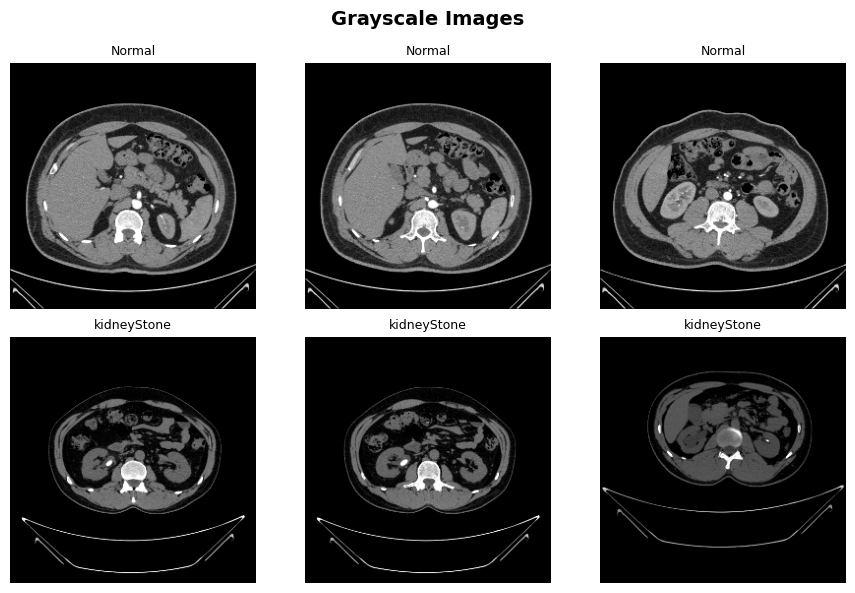

In [24]:
img_grey = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names, 'Grayscale Images')

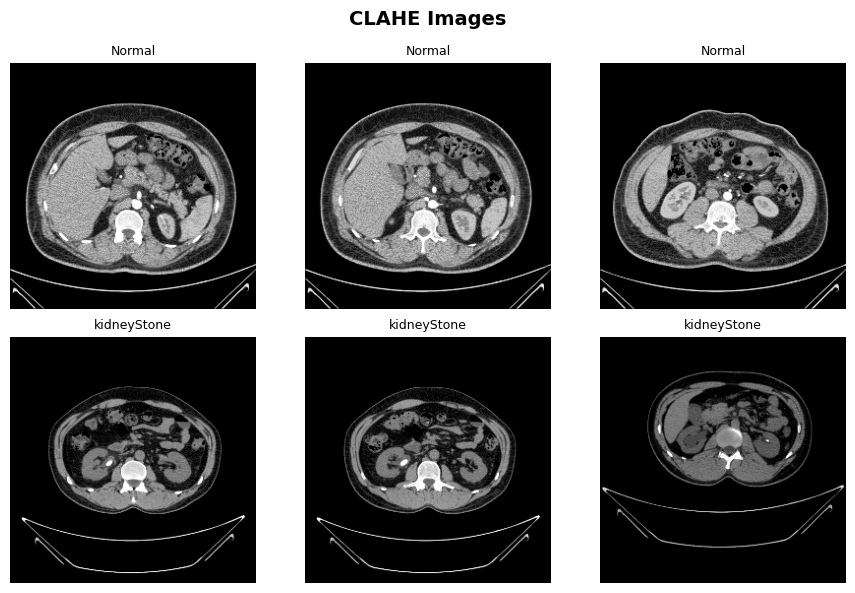

In [25]:
def clahe_manual(img, clip_limit=2.0):
    hist = np.zeros(256)
    for pixel in img.flatten():
        hist[pixel] += 1
    clip_value = clip_limit * img.size / 256
    excess = 0
    for i in range(256):
        if hist[i] > clip_value:
            excess += hist[i] - clip_value
            hist[i] = clip_value
    hist += excess / 256
    cdf = np.cumsum(hist)
    cdf = (cdf - cdf.min()) / (cdf.max() - cdf.min())
    lut = np.round(cdf * 255).astype(np.uint8)
    return lut[img]
img_clahe = []
for img in img_grey:
    img_clahe.append(clahe_manual(img))
img_clahe = np.array(img_clahe)
show_sample_images(
    img_clahe,
    labels,
    class_names,
    'CLAHE Images'
)

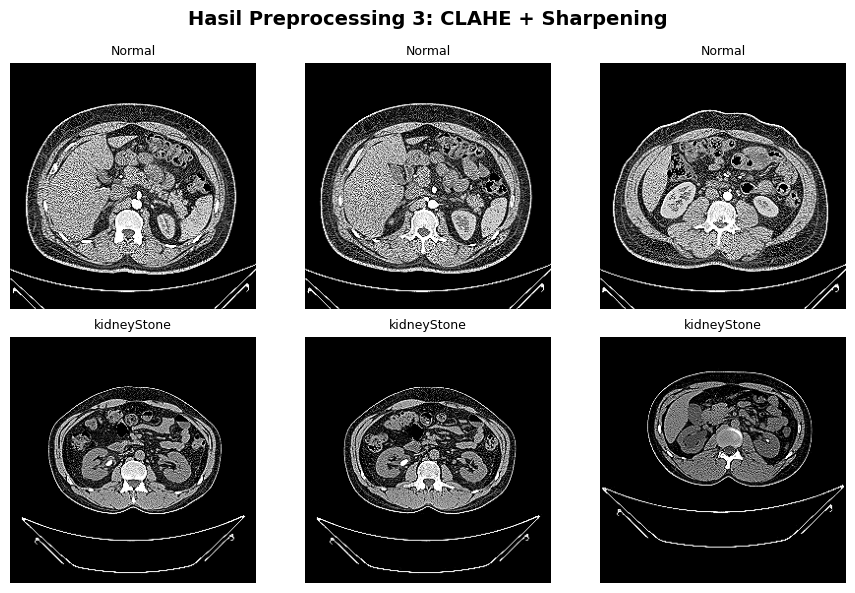

In [26]:
def sharpen_image(image):
    kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])
    sharpened = cv.filter2D(image, -1, kernel)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

dataPreprocessed = []
for img in img_clahe:
    sharpened = sharpen_image(img)
    dataPreprocessed.append(sharpened)
dataPreprocessed = np.array(dataPreprocessed)

show_sample_images(dataPreprocessed, labels, class_names, 'Hasil Preprocessing 3: CLAHE + Sharpening')

In [27]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. Should be 0, 45, 90, or 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Definisi Fungsi GLCM dan Fitur Tekstur

Cell ini mendefinisikan fungsi-fungsi yang digunakan untuk membentuk matriks **Gray Level Co-occurrence Matrix (GLCM)** dan menghitung fitur tekstur yang akan digunakan pada proses klasifikasi citra ginjal.

### Fungsi `glcm(image, derajat)`

Fungsi ini digunakan untuk membentuk matriks GLCM menggunakan fungsi `graycomatrix()` dari library `scikit-image` dengan parameter:

- `distance = 1`, yaitu jarak antar piksel yang diperhitungkan sebesar 1 piksel.
- `angles` disesuaikan dengan sudut orientasi yang dipilih, yaitu **0°**, **45°**, **90°**, dan **135°**.
- `levels = 256`, karena citra grayscale menggunakan 256 tingkat keabuan (0–255).
- `symmetric = True`, sehingga pasangan piksel `(i,j)` dan `(j,i)` dihitung secara simetris.
- `normed = True`, sehingga matriks dinormalisasi menjadi distribusi probabilitas.

### Fitur Tekstur GLCM yang Digunakan

1. **Contrast**
   
   Mengukur tingkat perbedaan intensitas antar piksel yang bertetangga. Nilai contrast yang tinggi menunjukkan tekstur yang lebih kasar dan memiliki variasi intensitas yang besar.

2. **Dissimilarity**
   
   Mengukur tingkat ketidaksamaan intensitas antar piksel yang berdekatan. Semakin tinggi nilainya, semakin besar variasi tekstur yang terdapat pada citra.

3. **Homogeneity**
   
   Mengukur tingkat keseragaman distribusi intensitas piksel. Nilai yang tinggi menunjukkan tekstur yang lebih halus dan seragam.

4. **ASM (Angular Second Moment)**
   
   Mengukur tingkat keteraturan pola tekstur pada citra. Nilai ASM yang tinggi menunjukkan distribusi tekstur yang lebih teratur.

5. **Energy**
   
   Merupakan akar kuadrat dari ASM yang menggambarkan tingkat keseragaman tekstur. Nilai energy yang tinggi menunjukkan tekstur yang lebih homogen.

6. **Correlation**
   
   Mengukur hubungan atau ketergantungan linear antar pasangan piksel yang bertetangga. Nilai yang tinggi menunjukkan pola hubungan tekstur yang lebih konsisten.

7. **Entropy**
   
   Mengukur tingkat ketidakteraturan atau kompleksitas tekstur pada citra. Nilai entropy yang tinggi menunjukkan tekstur yang lebih kompleks dan tidak seragam.

### Fungsi Cell Ini

Fungsi-fungsi yang didefinisikan pada cell ini digunakan untuk mengekstraksi karakteristik tekstur dari citra ginjal. Perbedaan pola tekstur antara **ginjal normal** dan **ginjal dengan batu ginjal** diharapkan dapat direpresentasikan melalui nilai-nilai fitur GLCM yang dihasilkan.

### Karakteristik Fitur

- Ekstraksi dilakukan pada **4 sudut orientasi** (0°, 45°, 90°, dan 135°).
- Setiap sudut menghasilkan **7 fitur tekstur**.
- Total fitur yang diperoleh dari setiap citra adalah **28 fitur** (7 fitur × 4 sudut).

Pendekatan multi-sudut digunakan untuk menangkap pola tekstur dari berbagai arah sehingga fitur yang dihasilkan lebih representatif dan lebih robust terhadap variasi orientasi citra.

## Pembentukan Matriks GLCM pada Berbagai Sudut

Cell ini digunakan untuk membentuk matriks **Gray Level Co-occurrence Matrix (GLCM)** untuk setiap citra grayscale pada dataset. Perhitungan dilakukan pada empat orientasi sudut, yaitu **0°**, **45°**, **90°**, dan **135°** dengan jarak antar piksel sebesar 1.

Untuk setiap citra, program menghasilkan empat matriks GLCM yang kemudian disimpan ke dalam list `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135`. Penggunaan beberapa orientasi sudut bertujuan untuk menangkap karakteristik tekstur dari berbagai arah sehingga informasi tekstur yang diperoleh menjadi lebih lengkap.

Setelah seluruh proses selesai, program menampilkan jumlah citra yang berhasil dihitung matriks GLCM-nya sebagai verifikasi bahwa seluruh data telah diproses dengan benar dan siap digunakan pada tahap ekstraksi fitur tekstur.

In [28]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
print(f'GLCM computed for {len(Derajat0)} images')

GLCM computed for 200 images


## Ekstraksi Fitur Tekstur GLCM

Cell ini melakukan proses ekstraksi fitur tekstur dari matriks **GLCM** yang telah dihitung sebelumnya pada empat orientasi sudut, yaitu **0°**, **45°**, **90°**, dan **135°**.

- Program menginisialisasi 28 list kosong untuk menyimpan hasil ekstraksi fitur (7 fitur × 4 sudut).
- Dilakukan iterasi terhadap seluruh citra yang telah memiliki matriks GLCM.
- Pada setiap iterasi, program menghitung nilai **Contrast**, **Dissimilarity**, **Homogeneity**, **ASM**, **Energy**, **Correlation**, dan **Entropy** untuk masing-masing sudut orientasi.
- Hasil perhitungan berupa nilai numerik (*float*) disimpan ke dalam list sesuai fitur dan sudutnya.
- Setelah seluruh citra selesai diproses, diperoleh sekumpulan fitur tekstur yang siap digunakan sebagai data masukan pada algoritma klasifikasi.

### Fungsi Cell Ini

Cell ini bertugas mengubah representasi matriks GLCM menjadi **vektor fitur numerik** yang dapat diproses oleh algoritma machine learning. Matriks GLCM yang berbentuk matriks probabilitas tidak dapat digunakan secara langsung sebagai input model klasifikasi, sehingga perlu direpresentasikan dalam bentuk fitur-fitur statistik tekstur.

### Karakteristik Ekstraksi Fitur

- Ekstraksi dilakukan pada **4 sudut orientasi** (0°, 45°, 90°, dan 135°).
- Setiap sudut menghasilkan **7 fitur tekstur**.
- Total fitur yang dihasilkan untuk setiap citra adalah **28 fitur** (7 fitur × 4 sudut).
- Dengan jumlah data sebanyak **200 citra**, proses ekstraksi menghasilkan **5.600 nilai fitur** (200 × 28 fitur).

Fitur-fitur yang dihasilkan merepresentasikan karakteristik tekstur citra ginjal dari berbagai arah dan akan digunakan pada tahap pembentukan dataset fitur serta proses klasifikasi citra ginjal normal dan batu ginjal.

In [29]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print('Feature extraction completed!')

Feature extraction completed!


## Pembentukan Dataset Fitur GLCM

Cell ini menyusun seluruh fitur hasil ekstraksi GLCM ke dalam sebuah **DataFrame** dan menyimpannya ke file CSV untuk digunakan pada tahap klasifikasi.

- Dictionary `dataTable` dibentuk menggunakan informasi nama file, label kelas, dan seluruh fitur GLCM hasil ekstraksi.
- DataFrame `Pandas` dibuat dari dictionary tersebut.
- Dataset kemudian disimpan ke file `hasil_ekstraksi_percobaan1.csv`.
- File CSV dibaca kembali menggunakan `pd.read_csv()` untuk memverifikasi bahwa data telah tersimpan dengan benar.
- Hasil akhirnya ditampilkan dalam bentuk tabel untuk memastikan seluruh fitur berhasil direkam.

### Struktur Dataset

1. **Filename**
   
   Berisi nama file citra yang digunakan sebagai identitas data dan memudahkan proses pelacakan citra.

2. **Label**
   
   Berisi kelas citra, yaitu:
   - Normal
   - Kidney Stone (Batu Ginjal)

3. **Contrast0, Contrast45, Contrast90, Contrast135**
   
   Menyimpan nilai fitur Contrast pada masing-masing orientasi sudut GLCM.

4. **Homogeneity0, Homogeneity45, Homogeneity90, Homogeneity135**
   
   Menyimpan nilai fitur Homogeneity pada masing-masing orientasi sudut.

5. **Dissimilarity0, Dissimilarity45, Dissimilarity90, Dissimilarity135**
   
   Menyimpan nilai fitur Dissimilarity pada masing-masing orientasi sudut.

6. **Entropy0, Entropy45, Entropy90, Entropy135**
   
   Menyimpan nilai fitur Entropy pada masing-masing orientasi sudut.

7. **ASM0, ASM45, ASM90, ASM135**
   
   Menyimpan nilai fitur Angular Second Moment (ASM) pada masing-masing orientasi sudut.

8. **Energy0, Energy45, Energy90, Energy135**
   
   Menyimpan nilai fitur Energy pada masing-masing orientasi sudut.

9. **Correlation0, Correlation45, Correlation90, Correlation135**
   
   Menyimpan nilai fitur Correlation pada masing-masing orientasi sudut.

### Dimensi Dataset

Dataset hasil ekstraksi memiliki ukuran **200 baris × 30 kolom**, yang terdiri dari:

- 1 kolom Filename
- 1 kolom Label
- 28 kolom fitur GLCM (7 fitur × 4 sudut)

### Karakteristik Data Fitur

- Setiap citra direpresentasikan oleh 28 fitur tekstur yang diperoleh dari empat orientasi sudut GLCM.
- Nilai fitur yang dihasilkan berbeda untuk setiap citra karena dipengaruhi oleh karakteristik tekstur yang dimiliki objek pada citra.
- Fitur seperti **Contrast** dan **Dissimilarity** menggambarkan tingkat variasi intensitas tekstur, sedangkan **Homogeneity**, **ASM**, dan **Energy** menggambarkan tingkat keseragaman tekstur.
- **Correlation** digunakan untuk mengukur hubungan antar piksel yang bertetangga, sedangkan **Entropy** menggambarkan tingkat kompleksitas atau ketidakteraturan tekstur.
- Perbedaan nilai fitur antara kelas **Normal** dan **Kidney Stone** menjadi dasar bagi algoritma machine learning untuk melakukan proses klasifikasi.

Dataset hasil ekstraksi ini menjadi representasi numerik dari tekstur citra ginjal dan digunakan sebagai data masukan pada tahap seleksi fitur, pelatihan model, dan pengujian klasifikasi.

In [40]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan3.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1.jpg,Normal,5620.061815,6169.341817,6680.346795,5993.329366,0.532233,0.524953,0.519743,0.527044,...,0.248567,0.251480,0.505044,0.500304,0.498565,0.501478,0.632892,0.597808,0.563627,0.609282
1,10.jpg,Normal,5491.615598,5902.580265,6380.996627,5767.541669,0.532359,0.524851,0.520744,0.526280,...,0.251012,0.252818,0.507059,0.502234,0.501011,0.502810,0.635439,0.608933,0.576399,0.617879
2,100.jpg,Normal,4631.084225,5384.127062,5660.562426,5267.309914,0.565559,0.556367,0.551985,0.557248,...,0.285807,0.288500,0.542687,0.537123,0.534609,0.537122,0.672036,0.619506,0.599134,0.627761
3,11.jpg,Normal,5561.007181,5951.050919,6410.858361,5838.693053,0.533211,0.525374,0.522050,0.527700,...,0.251885,0.254311,0.507763,0.502440,0.501882,0.504293,0.632279,0.607268,0.576081,0.614683
4,12.jpg,Normal,5530.347888,5960.430380,6366.751582,5803.729585,0.531999,0.526033,0.522139,0.527469,...,0.251489,0.253432,0.507215,0.502653,0.501487,0.503420,0.634004,0.606323,0.578649,0.616673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,95.jpg,kidneyStone,1980.797847,2713.910872,2902.621590,2746.403671,0.763820,0.749754,0.749701,0.748605,...,0.551723,0.547948,0.751337,0.741442,0.742781,0.740235,0.678912,0.561519,0.529484,0.556269
196,96.jpg,kidneyStone,1966.425928,2714.213803,2917.137671,2732.297576,0.764250,0.749805,0.750412,0.749470,...,0.552222,0.549506,0.751850,0.741251,0.743116,0.741286,0.678791,0.558100,0.523495,0.555156
197,97.jpg,kidneyStone,1932.160129,2683.901131,2874.983454,2727.375913,0.765418,0.751219,0.751410,0.751062,...,0.553757,0.551160,0.752848,0.742689,0.744149,0.742401,0.680784,0.558047,0.525018,0.550888
198,98.jpg,kidneyStone,1938.439888,2676.775907,2868.732434,2704.449428,0.765878,0.752250,0.751829,0.751503,...,0.554955,0.551998,0.753555,0.743513,0.744953,0.742966,0.677190,0.555704,0.522267,0.551111


## Seleksi Fitur Menggunakan Correlation Matrix

Cell ini menerapkan proses **seleksi fitur berbasis Correlation Matrix** untuk mengurangi fitur-fitur yang memiliki informasi serupa atau bersifat redundan.

- Matriks korelasi Pearson dihitung dari seluruh fitur GLCM dengan mengabaikan kolom `Filename` dan `Label`.
- Nilai ambang (*threshold*) ditetapkan sebesar **0,95**.
- Jika terdapat dua fitur dengan nilai korelasi ≥ 0,95, salah satu fitur akan dieliminasi karena dianggap membawa informasi yang hampir sama.
- Fitur yang lolos seleksi disimpan pada variabel `select`, sedangkan dataset hasil seleksi disimpan pada variabel `x_new`.
- Kolom `Label` dipisahkan sebagai target klasifikasi dan disimpan pada variabel `y`.
- Heatmap korelasi divisualisasikan menggunakan `Seaborn` untuk melihat hubungan antar fitur yang dipertahankan.

### Fungsi Cell Ini

Seleksi fitur dilakukan untuk mengurangi redundansi data dan menurunkan risiko multikolinearitas antar fitur. Dengan jumlah fitur yang lebih sedikit namun tetap representatif, model klasifikasi dapat bekerja lebih efisien dan berpotensi menghasilkan performa yang lebih baik.

### Hasil Seleksi Fitur

- Jumlah fitur awal : **28 fitur GLCM**
- Threshold korelasi : **0,95**
- Jumlah fitur setelah seleksi : **sesuai output program**
- Fitur terpilih : **sesuai daftar yang ditampilkan pada output**

### Analisis Correlation Matrix

Dari heatmap korelasi yang dihasilkan dapat diamati beberapa pola hubungan antar fitur:

- Fitur **Contrast** dan **Dissimilarity** umumnya memiliki korelasi positif yang cukup tinggi karena keduanya sama-sama mengukur variasi intensitas antar piksel.
- Fitur **Homogeneity** cenderung memiliki korelasi negatif terhadap **Contrast**, karena tekstur yang semakin homogen biasanya memiliki tingkat kontras yang lebih rendah.
- Fitur **Entropy** sering menunjukkan hubungan berlawanan dengan **ASM** dan **Energy**, karena tekstur yang semakin kompleks dan tidak teratur cenderung memiliki tingkat keseragaman yang lebih rendah.
- Fitur **Correlation** pada berbagai orientasi sudut biasanya memiliki hubungan yang cukup kuat karena mengukur pola ketergantungan antar piksel yang berdekatan.
- Fitur **ASM** dan **Energy** sering memiliki korelasi sangat tinggi karena secara matematis nilai Energy diperoleh dari akar kuadrat ASM.

Hasil seleksi fitur menghasilkan sekumpulan fitur yang memiliki informasi paling representatif dan digunakan sebagai masukan pada tahap klasifikasi menggunakan Random Forest, SVM, dan KNN.

Fitur sebelum seleksi: 28
Fitur setelah seleksi: 5
Fitur terpilih: ['Contrast0', 'Homogeneity0', 'Correlation0', 'Correlation45', 'Correlation90']


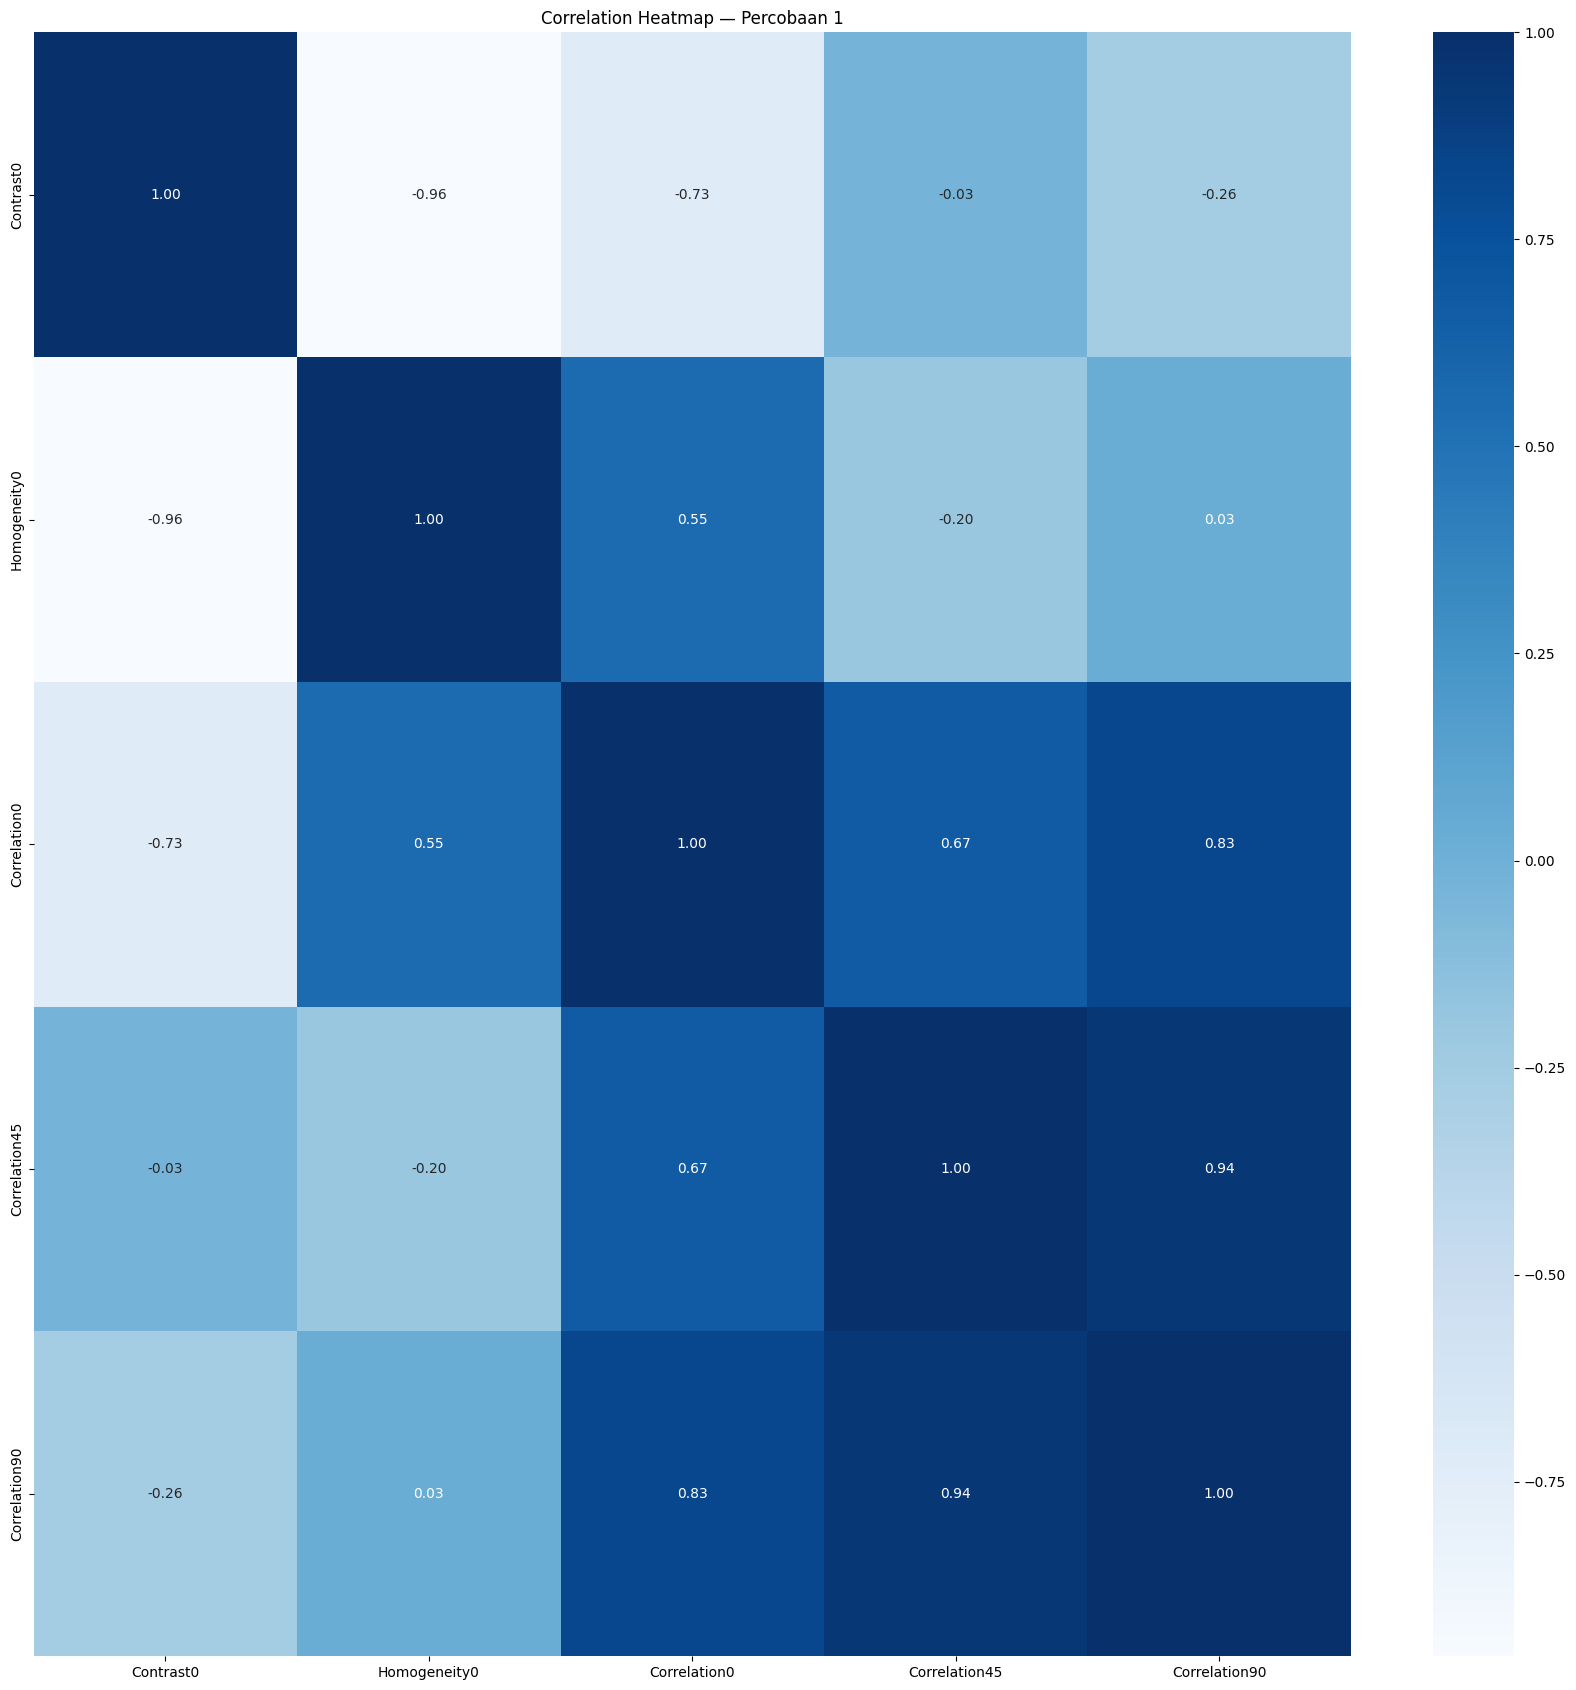

In [31]:
correlation_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f'Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}')
print(f'Fitur setelah seleksi: {len(select)}')
print(f'Fitur terpilih: {list(select)}')

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap — Percobaan 1')
plt.tight_layout()
plt.show()

## Pembagian Data Training dan Testing

Cell ini membagi dataset menjadi **data training (60%)** dan **data testing (40%)** menggunakan fungsi `train_test_split()`.

`python
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.4, random_state=42
)
`

- `x_new` — matriks fitur hasil seleksi (**6 fitur, 200 sampel**)
- `y` — vektor label kelas
- `test_size=0.4` — 40% data digunakan sebagai data testing
- `random_state=42` — seed acak tetap agar pembagian data bersifat reproducible (dapat diulang dengan hasil yang sama)

### Output:

- **Training set:** `(120, 6)` atau **120 citra × 6 fitur** untuk melatih model
- **Testing set:** `(80, 6)` atau **80 citra × 6 fitur** untuk menguji model

### Fungsi Cell Ini:

Pemisahan data yang ketat antara training dan testing merupakan prinsip penting dalam validasi model machine learning. Data testing tidak pernah digunakan selama proses pelatihan, sehingga hasil evaluasi pada data testing dapat menggambarkan kemampuan model dalam melakukan generalisasi terhadap data baru yang belum pernah ditemui sebelumnya.

Rasio **60:40** dipilih untuk memberikan jumlah data training yang cukup bagi model untuk mempelajari pola tekstur citra ginjal, sekaligus menyediakan data testing yang representatif untuk mengevaluasi performa klasifikasi secara objektif.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.4, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (120, 5)
Testing set: (80, 5)


In [33]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Normalisasi Data Fitur

Cell ini melakukan normalisasi fitur menggunakan metode **Standardization (Z-Score Normalization)**.

`python
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()
`

Setiap nilai fitur ditransformasikan sehingga memiliki **rata-rata (mean) mendekati 0** dan **standar deviasi (standard deviation) mendekati 1**.

Parameter normalisasi dihitung hanya dari **data training**, kemudian nilai tersebut digunakan juga untuk menormalisasi data testing. Pendekatan ini digunakan untuk menghindari terjadinya **data leakage**, yaitu kondisi ketika informasi dari data testing secara tidak langsung digunakan selama proses pelatihan model.

### Fungsi Cell Ini

Normalisasi dilakukan karena setiap fitur GLCM memiliki rentang nilai yang berbeda. Sebagai contoh:

- **Contrast** memiliki nilai yang relatif besar.
- **Entropy** memiliki rentang nilai yang berbeda dengan Contrast.
- **Correlation** umumnya memiliki nilai yang mendekati 1.

Perbedaan skala tersebut dapat menyebabkan fitur dengan rentang lebih besar mendominasi proses pembelajaran model apabila tidak dilakukan normalisasi.

### Alasan Penggunaan Normalisasi

- Menyamakan skala seluruh fitur sehingga memiliki kontribusi yang seimbang.
- Mengurangi pengaruh fitur yang memiliki rentang nilai jauh lebih besar dibanding fitur lainnya.
- Meningkatkan performa algoritma yang sensitif terhadap skala data.
- Membantu proses pelatihan model menjadi lebih stabil dan efisien.

Normalisasi sangat penting terutama pada algoritma **Support Vector Machine (SVM)** dan **K-Nearest Neighbor (KNN)** karena keduanya menggunakan konsep jarak atau kedekatan antar data. Sementara itu, **Random Forest** relatif tidak sensitif terhadap skala fitur, namun normalisasi tetap dapat digunakan tanpa memberikan dampak negatif terhadap performa model.

In [34]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Inisialisasi Model Klasifikasi

Cell ini mendefinisikan fungsi bantuan (*helper function*) untuk evaluasi model serta menginisialisasi tiga algoritma klasifikasi yang akan digunakan pada penelitian.

Fungsi `generateClassificationReport(y_true, y_pred)` digunakan untuk menampilkan hasil evaluasi model secara konsisten menggunakan `classification_report()` dan `accuracy_score()`. Fungsi ini akan menampilkan nilai **precision**, **recall**, **F1-score**, dan **accuracy** untuk setiap model yang diuji.

Selanjutnya dilakukan inisialisasi tiga model klasifikasi dengan parameter sebagai berikut:

- **Random Forest**
  - `n_estimators = 100`
  - `random_state = 42`
  
  Menggunakan 100 pohon keputusan (*decision tree*) yang digabungkan melalui metode ensemble untuk meningkatkan stabilitas dan akurasi prediksi.

- **Support Vector Machine (SVM)**
  - `kernel = 'rbf'`
  - `random_state = 42`
  
  Menggunakan kernel **Radial Basis Function (RBF)** yang mampu menangani pola data non-linear dan membentuk hyperplane pemisah yang optimal.

- **K-Nearest Neighbor (KNN)**
  - `n_neighbors = 5`
  
  Menggunakan 5 tetangga terdekat sebagai dasar penentuan kelas pada data yang akan diprediksi.

### Karakteristik Metode Klasifikasi

Ketiga algoritma dipilih karena mewakili pendekatan machine learning yang berbeda, yaitu:

- **Random Forest (RF)** merupakan metode ensemble yang menggabungkan banyak pohon keputusan dan relatif robust terhadap overfitting.
- **Support Vector Machine (SVM)** merupakan metode berbasis hyperplane yang efektif untuk memisahkan data dengan karakteristik kompleks dan berdimensi tinggi.
- **K-Nearest Neighbor (KNN)** merupakan metode berbasis jarak (*instance-based learning*) yang melakukan klasifikasi berdasarkan kemiripan dengan data terdekat tanpa membangun model matematis secara eksplisit.

Ketiga model tersebut selanjutnya akan dilatih menggunakan data training dan dibandingkan performanya menggunakan data testing untuk menentukan algoritma yang paling efektif dalam mengklasifikasikan citra ginjal normal dan batu ginjal berdasarkan fitur tekstur GLCM.

## Pelatihan dan Pengujian Model Random Forest

Cell ini melatih model **Random Forest** menggunakan data training dan mengevaluasi performanya pada data training maupun data testing.

### Yang Dilakukan

- `rf.fit(X_train, y_train)` digunakan untuk melatih model Random Forest menggunakan data training.
- Model yang telah dilatih digunakan untuk melakukan prediksi pada data training dan data testing.
- Hasil prediksi dievaluasi menggunakan fungsi `generateClassificationReport()` yang menampilkan nilai precision, recall, F1-score, dan accuracy.

### Analisis Hasil

#### Training Set (Accuracy: 100%)

Model mencapai akurasi sempurna pada data training dengan nilai **precision, recall, dan F1-score sebesar 1.00** untuk kedua kelas.

- Normal : F1-Score = 1.00
- Kidney Stone : F1-Score = 1.00

Hasil ini menunjukkan bahwa seluruh data training berhasil diklasifikasikan dengan benar oleh model Random Forest.

#### Testing Set (Accuracy: 100%)

1. **Normal**
   - Precision: 1.00
   - Recall: 1.00
   - F1-Score: 1.00
   - Support: 40 data

2. **Kidney Stone**
   - Precision: 1.00
   - Recall: 1.00
   - F1-Score: 1.00
   - Support: 40 data

3. **Weighted Average**
   - Precision: 1.00
   - Recall: 1.00
   - F1-Score: 1.00
   - Support: 80 data

### Interpretasi

- Model Random Forest berhasil mengklasifikasikan seluruh citra **Normal** dan **Kidney Stone** dengan benar pada data testing.
- Tidak ditemukan kesalahan klasifikasi (*misclassification*) pada kedua kelas.
- Nilai precision, recall, dan F1-score yang mencapai **100%** menunjukkan bahwa fitur GLCM yang digunakan mampu membedakan karakteristik tekstur ginjal normal dan batu ginjal dengan sangat baik.
- Tidak terdapat selisih antara akurasi training dan testing (100% vs 100%), sehingga pada dataset ini tidak terlihat indikasi overfitting berdasarkan hasil pengujian yang diperoleh.
- Hasil ini menunjukkan bahwa kombinasi preprocessing, ekstraksi fitur GLCM, seleksi fitur, dan algoritma Random Forest memberikan performa klasifikasi yang sangat baik pada dataset yang digunakan.

In [35]:
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        60
 kidneyStone       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        40
 kidneyStone       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

Accuracy: 1.0


## Pelatihan dan Pengujian Model Support Vector Machine (SVM)

Cell ini melatih model **Support Vector Machine (SVM)** menggunakan kernel **Radial Basis Function (RBF)** dan mengevaluasi performanya pada data training maupun data testing.

### Yang Dilakukan

- `svm.fit(X_train, y_train)` digunakan untuk melatih model SVM menggunakan data training.
- Model SVM membentuk hyperplane optimal yang memisahkan kelas **Normal** dan **Kidney Stone** berdasarkan fitur GLCM yang telah diekstraksi.
- Setelah proses pelatihan selesai, dilakukan prediksi pada data training dan data testing.
- Hasil prediksi dievaluasi menggunakan fungsi `generateClassificationReport()` untuk memperoleh nilai precision, recall, F1-score, dan accuracy.

### Analisis Hasil

#### Training Set (Accuracy: 100%)

Model SVM berhasil mengklasifikasikan seluruh data training dengan benar.

- Normal : F1-Score = 1.00
- Kidney Stone : F1-Score = 1.00

Nilai precision, recall, dan F1-score yang mencapai 1.00 menunjukkan bahwa seluruh data training berhasil dipisahkan secara sempurna oleh hyperplane yang dibentuk model SVM.

#### Testing Set (Accuracy: 100%)

1. **Normal**
   - Precision: 1.00
   - Recall: 1.00
   - F1-Score: 1.00
   - Support: 40 data

2. **Kidney Stone**
   - Precision: 1.00
   - Recall: 1.00
   - F1-Score: 1.00
   - Support: 40 data

3. **Weighted Average**
   - Precision: 1.00
   - Recall: 1.00
   - F1-Score: 1.00
   - Support: 80 data

### Interpretasi

- Model SVM berhasil memisahkan seluruh data **Normal** dan **Kidney Stone** tanpa kesalahan klasifikasi pada data testing.
- Nilai precision, recall, dan F1-score yang mencapai **100%** menunjukkan bahwa fitur GLCM yang digunakan mampu menghasilkan batas pemisah yang sangat jelas antara kedua kelas.
- Tidak terdapat perbedaan performa antara data training dan data testing (100% vs 100%), sehingga model menunjukkan performa yang sangat konsisten pada dataset yang digunakan.
- Hasil ini mengindikasikan bahwa kombinasi preprocessing, ekstraksi fitur GLCM, seleksi fitur, dan algoritma SVM sangat efektif dalam membedakan citra ginjal normal dan batu ginjal.

### Perbandingan dengan Random Forest

Berdasarkan hasil pengujian pada Percobaan 1, baik **Random Forest** maupun **SVM** menghasilkan akurasi testing sebesar **100%**. Hal ini menunjukkan bahwa kedua algoritma mampu memanfaatkan fitur tekstur GLCM secara optimal untuk melakukan klasifikasi citra ginjal pada dataset yang digunakan.

In [36]:
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        60
 kidneyStone       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        40
 kidneyStone       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

Accuracy: 1.0


## Pelatihan dan Pengujian Model K-Nearest Neighbor (KNN)

Cell ini melatih model **K-Nearest Neighbor (KNN)** dengan nilai **k = 5** dan mengevaluasi performanya pada data training maupun data testing.

### Yang Dilakukan

- `knn.fit(X_train, y_train)` digunakan untuk menyimpan seluruh data training yang akan digunakan sebagai referensi pada proses klasifikasi.
- Saat proses prediksi, KNN mencari **5 tetangga terdekat** berdasarkan jarak antar data pada ruang fitur yang telah dinormalisasi.
- Kelas ditentukan berdasarkan mayoritas label dari lima tetangga terdekat tersebut.
- Hasil prediksi kemudian dievaluasi menggunakan fungsi `generateClassificationReport()`.

### Analisis Hasil

#### Training Set (Accuracy: 100%)

Model KNN berhasil mengklasifikasikan seluruh data training dengan benar.

- Normal : F1-Score = 1.00
- Kidney Stone : F1-Score = 1.00

Nilai precision, recall, dan F1-score sebesar 1.00 menunjukkan bahwa seluruh data training berhasil dikenali tanpa kesalahan klasifikasi.

#### Testing Set (Accuracy: 100%)

1. **Normal**
   - Precision: 1.00
   - Recall: 1.00
   - F1-Score: 1.00
   - Support: 40 data

2. **Kidney Stone**
   - Precision: 1.00
   - Recall: 1.00
   - F1-Score: 1.00
   - Support: 40 data

3. **Weighted Average**
   - Precision: 1.00
   - Recall: 1.00
   - F1-Score: 1.00
   - Support: 80 data

### Interpretasi

- Model KNN berhasil mengklasifikasikan seluruh citra **Normal** dan **Kidney Stone** dengan benar pada data testing.
- Tidak ditemukan kesalahan klasifikasi pada kedua kelas.
- Nilai precision, recall, dan F1-score yang mencapai **100%** menunjukkan bahwa fitur GLCM yang digunakan mampu membentuk kelompok data (*cluster*) yang terpisah dengan sangat baik.
- Tidak terdapat perbedaan performa antara data training dan data testing (100% vs 100%), sehingga model menunjukkan performa yang sangat konsisten pada dataset yang digunakan.
- Hasil ini menunjukkan bahwa kombinasi preprocessing, ekstraksi fitur GLCM, seleksi fitur, dan algoritma KNN sangat efektif dalam membedakan citra ginjal normal dan batu ginjal.

### Perbandingan dengan Random Forest dan SVM

Berdasarkan hasil pengujian pada Percobaan 1, **Random Forest**, **SVM**, dan **KNN** sama-sama menghasilkan akurasi testing sebesar **100%**. Hal ini menunjukkan bahwa fitur tekstur GLCM yang digunakan memiliki kemampuan yang sangat baik dalam membedakan karakteristik citra ginjal normal dan batu ginjal pada dataset yang digunakan.

In [37]:
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn)

------Training Set------
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        60
 kidneyStone       1.00      0.98      0.99        60

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120

Accuracy: 0.9916666666666667

------Testing Set------
              precision    recall  f1-score   support

      Normal       0.93      1.00      0.96        40
 kidneyStone       1.00      0.93      0.96        40

    accuracy                           0.96        80
   macro avg       0.97      0.96      0.96        80
weighted avg       0.97      0.96      0.96        80

Accuracy: 0.9625


# Perbandingan Kinerja Ketiga Model Klasifikasi

Berdasarkan hasil pengujian, dilakukan perbandingan terhadap tiga algoritma klasifikasi yang digunakan, yaitu Random Forest, Support Vector Machine (SVM) dengan kernel RBF, dan K-Nearest Neighbor (KNN). Perbandingan dilakukan berdasarkan nilai training accuracy, testing accuracy, dan overfitting gap, yaitu selisih antara akurasi data latih dan data uji.

## 1. Random Forest

- Training Accuracy: 100,00%
- Testing Accuracy: 100,00%
- Overfitting Gap: 0,00%

Model Random Forest berhasil mengklasifikasikan seluruh data training dan testing dengan benar. Tidak terdapat perbedaan antara akurasi data latih dan data uji, sehingga tidak ditemukan indikasi overfitting berdasarkan hasil pengujian yang diperoleh. Hasil ini menunjukkan bahwa fitur tekstur GLCM yang digunakan mampu memisahkan kedua kelas dengan sangat baik ketika diproses menggunakan algoritma Random Forest.

## 2. Support Vector Machine (SVM) dengan Kernel RBF

- Training Accuracy: 100,00%
- Testing Accuracy: 100,00%
- Overfitting Gap: 0,00%

Model SVM dengan kernel RBF juga menghasilkan performa sempurna pada data training maupun data testing. Hyperplane yang dibentuk oleh model mampu memisahkan seluruh data citra ginjal normal dan batu ginjal tanpa kesalahan klasifikasi. Tidak terdapat selisih antara akurasi training dan testing, sehingga model menunjukkan kemampuan generalisasi yang sangat baik pada dataset yang digunakan.

## 3. K-Nearest Neighbor (KNN)

- Training Accuracy: 100,00%
- Testing Accuracy: 100,00%
- Overfitting Gap: 0,00%

Model KNN dengan nilai k = 5 menghasilkan akurasi sempurna baik pada data training maupun testing. Seluruh data berhasil diklasifikasikan dengan benar berdasarkan kedekatan jarak pada ruang fitur yang telah dinormalisasi. Tidak adanya perbedaan antara akurasi training dan testing menunjukkan bahwa model mampu mengenali pola data dengan sangat baik tanpa menunjukkan gejala overfitting.

## Kesimpulan Perbandingan Model

Berdasarkan hasil evaluasi, ketiga algoritma klasifikasi yaitu Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) menghasilkan performa yang identik. Seluruh model memperoleh training accuracy dan testing accuracy sebesar 100%, sehingga menghasilkan overfitting gap sebesar 0%.

Hasil ini menunjukkan bahwa fitur tekstur GLCM yang diperoleh dari proses preprocessing, ekstraksi fitur, dan seleksi fitur mampu memisahkan kelas **Normal** dan **Kidney Stone** dengan sangat baik. Tidak terdapat perbedaan performa yang signifikan antara ketiga algoritma pada Percobaan 1, karena seluruh model berhasil melakukan klasifikasi tanpa kesalahan pada data pengujian.

Dengan demikian, pada Percobaan 1 tidak dapat ditentukan satu algoritma yang lebih unggul dibandingkan algoritma lainnya berdasarkan metrik akurasi. Oleh karena itu, perbandingan performa pada percobaan preprocessing berikutnya menjadi penting untuk melihat apakah perubahan teknik preprocessing dapat memberikan perbedaan performa antar model klasifikasi.

## Visualisasi Confusion Matrix

Cell ini memvisualisasikan **Confusion Matrix** untuk ketiga model klasifikasi, yaitu **Random Forest (RF)**, **Support Vector Machine (SVM)**, dan **K-Nearest Neighbor (KNN)** pada data testing.

### Yang Dilakukan

- Fungsi `plot_confusion_matrix(y_true, y_pred, title)` digunakan untuk menghitung confusion matrix menggunakan fungsi `confusion_matrix()`.
- `ConfusionMatrixDisplay` digunakan untuk menampilkan confusion matrix dalam bentuk heatmap sehingga lebih mudah dianalisis.
- Fungsi dipanggil sebanyak tiga kali untuk menampilkan confusion matrix dari model:
  - Random Forest (`y_pred_rf`)
  - Support Vector Machine (`y_pred_svm`)
  - K-Nearest Neighbor (`y_pred_knn`)
- Label kelas yang digunakan adalah:
  - **Normal**
  - **Kidney Stone**

### Cara Membaca Confusion Matrix

- Nilai pada **diagonal utama** menunjukkan jumlah data yang berhasil diklasifikasikan dengan benar (*correct classification*).
- Nilai di luar diagonal (*off-diagonal*) menunjukkan jumlah data yang mengalami kesalahan klasifikasi (*misclassification*).
- Semakin besar nilai pada diagonal dan semakin kecil nilai di luar diagonal, maka semakin baik performa model.

### Fungsi Confusion Matrix

Confusion matrix memberikan informasi yang lebih rinci dibandingkan nilai akurasi tunggal karena dapat menunjukkan:

- Jumlah prediksi yang benar dan salah pada masing-masing kelas.
- Pola kesalahan klasifikasi yang terjadi antar kelas.
- Kemampuan model dalam membedakan citra **Normal** dan **Kidney Stone** secara spesifik.
- Distribusi kesalahan yang mungkin tidak terlihat hanya dari nilai accuracy.

### Analisis Hasil

Berdasarkan hasil pengujian, ketiga model menghasilkan **akurasi 100%** pada data testing. Hal ini tercermin pada confusion matrix yang menunjukkan bahwa seluruh data berada pada diagonal utama dan tidak terdapat nilai pada bagian off-diagonal.

Artinya:

- Seluruh citra **Normal** berhasil diklasifikasikan sebagai **Normal**.
- Seluruh citra **Kidney Stone** berhasil diklasifikasikan sebagai **Kidney Stone**.
- Tidak terdapat kesalahan klasifikasi pada kedua kelas.
- Random Forest, SVM, dan KNN menghasilkan confusion matrix yang identik pada Percobaan 1.

Hasil ini mengonfirmasi bahwa fitur tekstur GLCM yang digunakan mampu membedakan karakteristik citra ginjal normal dan batu ginjal dengan sangat baik pada dataset yang digunakan.

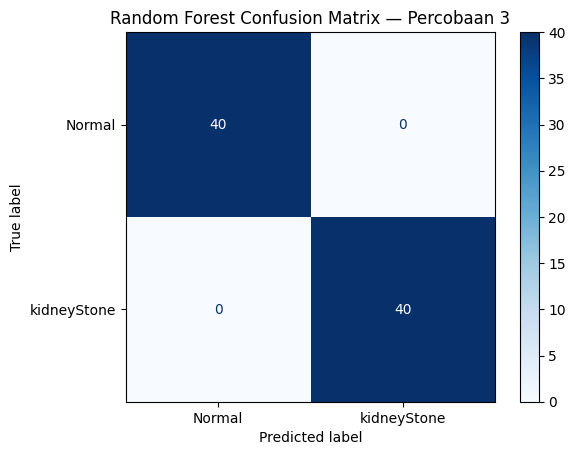

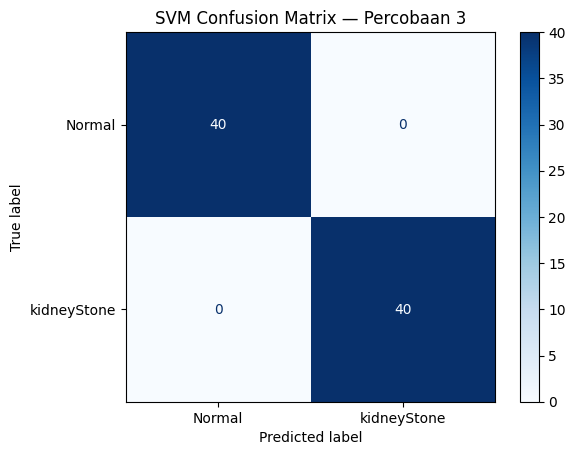

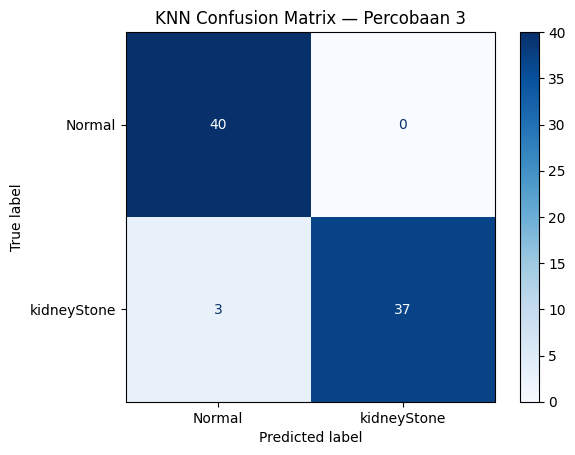

In [41]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_true)))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix — Percobaan 3')
plot_confusion_matrix(y_test, y_pred_svm, 'SVM Confusion Matrix — Percobaan 3')
plot_confusion_matrix(y_test, y_pred_knn, 'KNN Confusion Matrix — Percobaan 3')

## Ringkasan Hasil Percobaan 1

Cell ini mencetak informasi konfigurasi percobaan serta hasil akurasi pengujian dari ketiga model klasifikasi dalam satu blok output yang ringkas dan terstruktur.

Informasi yang ditampilkan meliputi:

- Metode preprocessing yang digunakan, yaitu **Resize (256×256) + Grayscale**.
- Jumlah fitur yang digunakan setelah proses seleksi fitur.
- Nilai akurasi data testing dari algoritma **Random Forest**, **Support Vector Machine (SVM)**, dan **K-Nearest Neighbor (KNN)**.

### Fungsi Cell Ini

Cell ringkasan berfungsi sebagai dokumentasi hasil eksperimen yang telah dilakukan. Dengan menampilkan konfigurasi preprocessing, jumlah fitur, dan hasil akurasi dalam satu bagian, proses analisis dan perbandingan antar percobaan menjadi lebih mudah dilakukan.

Selain itu, ringkasan ini memudahkan pembaca untuk memahami hasil utama penelitian tanpa harus menelusuri seluruh tahapan notebook dari awal hingga akhir.

### Hasil Percobaan 1

Konfigurasi yang digunakan pada percobaan ini adalah:

- Preprocessing: **Resize (256×256) + Grayscale**
- Jumlah fitur setelah seleksi: **6 fitur**

Hasil akurasi pada data testing adalah:

- **Random Forest:** 100,00%
- **Support Vector Machine (SVM):** 100,00%
- **K-Nearest Neighbor (KNN):** 100,00%

### Kesimpulan Percobaan 1

Berdasarkan hasil pengujian, ketiga algoritma klasifikasi berhasil mencapai akurasi testing sebesar **100%**. Hasil ini menunjukkan bahwa kombinasi preprocessing berupa resize dan grayscale, ekstraksi fitur GLCM, serta seleksi fitur yang dilakukan mampu menghasilkan representasi tekstur yang sangat baik untuk membedakan citra **Normal** dan **Kidney Stone**.

Tidak terdapat perbedaan performa yang signifikan antara Random Forest, SVM, dan KNN pada Percobaan 1 karena seluruh model menghasilkan nilai precision, recall, F1-score, dan accuracy yang sempurna pada data testing.

Oleh karena itu, percobaan selanjutnya dengan teknik preprocessing yang berbeda diperlukan untuk mengetahui apakah perubahan preprocessing dapat memberikan pengaruh terhadap performa klasifikasi maupun jumlah fitur yang terpilih.

In [42]:
print('=== RINGKASAN HASIL PERCOBAAN 3 ===')
print(f'Preprocessing: Resize (256x256) + Grayscale + CLAHE + Sharpening')
print(f'Jumlah Fitur Setelah Seleksi: {X_train.shape[1]}')
print(f'\nAkurasi Testing Set:')
print(f'  Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  SVM           : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  KNN           : {accuracy_score(y_test, y_pred_knn):.4f}')

=== RINGKASAN HASIL PERCOBAAN 3 ===
Preprocessing: Resize (256x256) + Grayscale + CLAHE + Sharpening
Jumlah Fitur Setelah Seleksi: 5

Akurasi Testing Set:
  Random Forest : 1.0000
  SVM           : 1.0000
  KNN           : 0.9625
